In [103]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage as ndi
import skimage as ski
from PIL import Image
import cv2

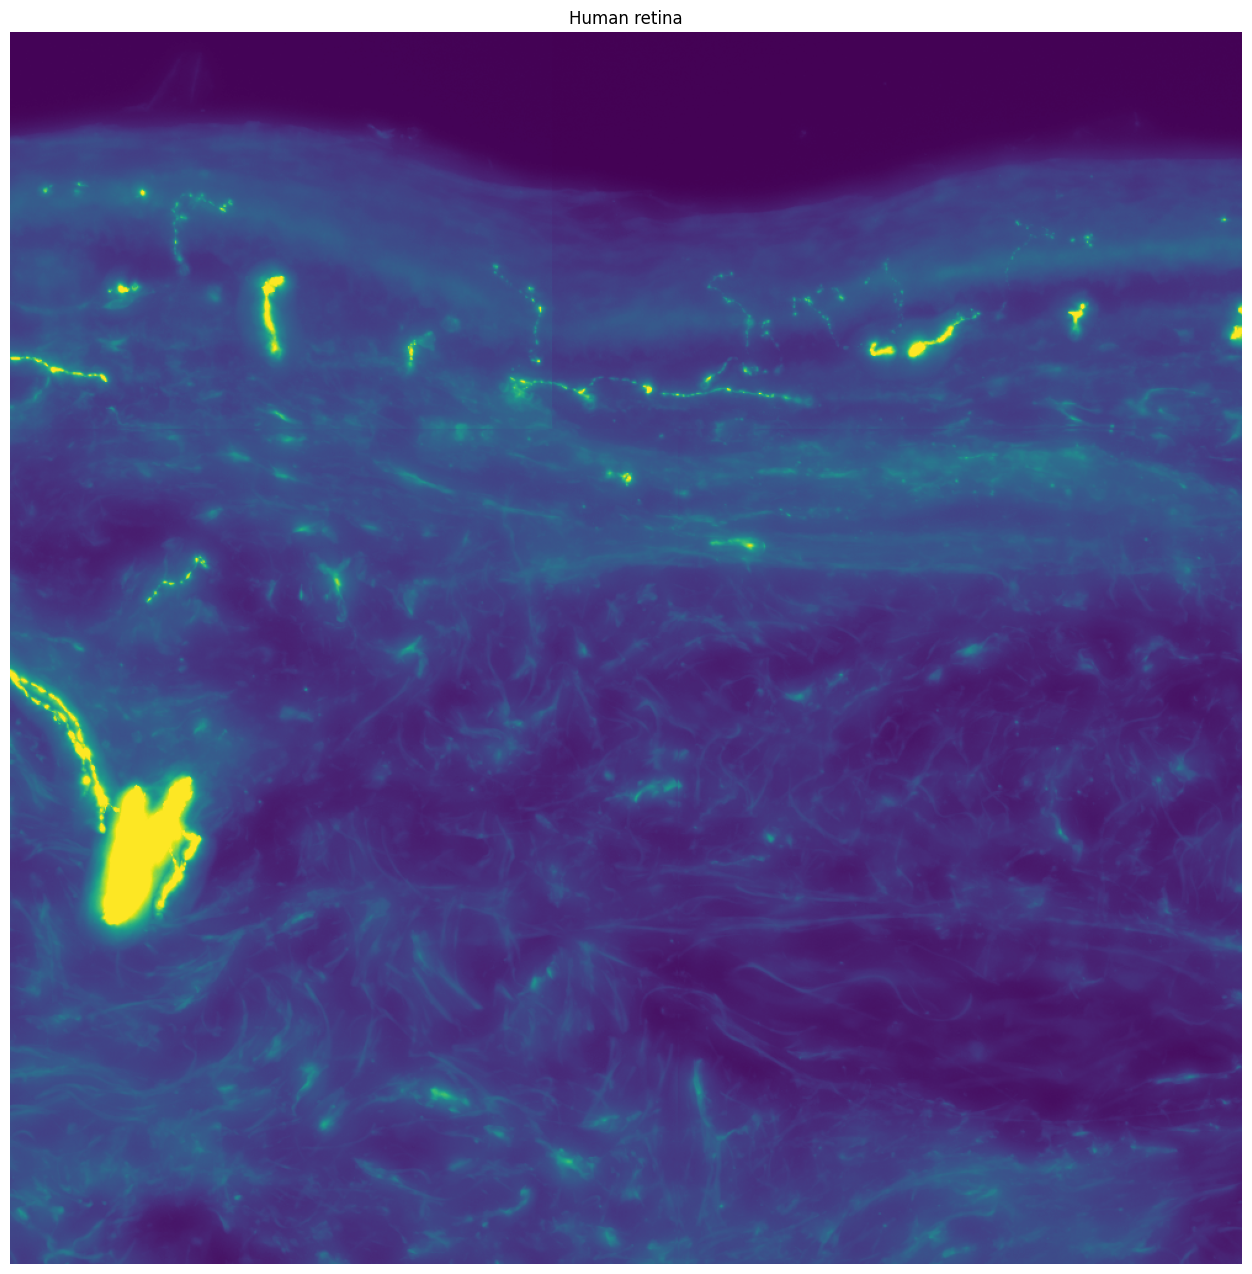

In [104]:
img = ski.io.imread('../data/S1585-2_a/image.png')  # 請替換成您的圖片路徑
# 提取綠色通道 (RGB 中的 G 通道)
green_channel = img[:, :, 1]

X =2325
Y = 600
W = 1000
H = 1000
# clip 小區域
green_channel = green_channel[Y:Y+H, X:X+W]

_, ax = plt.subplots(figsize=(16, 16))
ax.imshow(green_channel)
ax.set_axis_off()
_ = ax.set_title('Human retina')

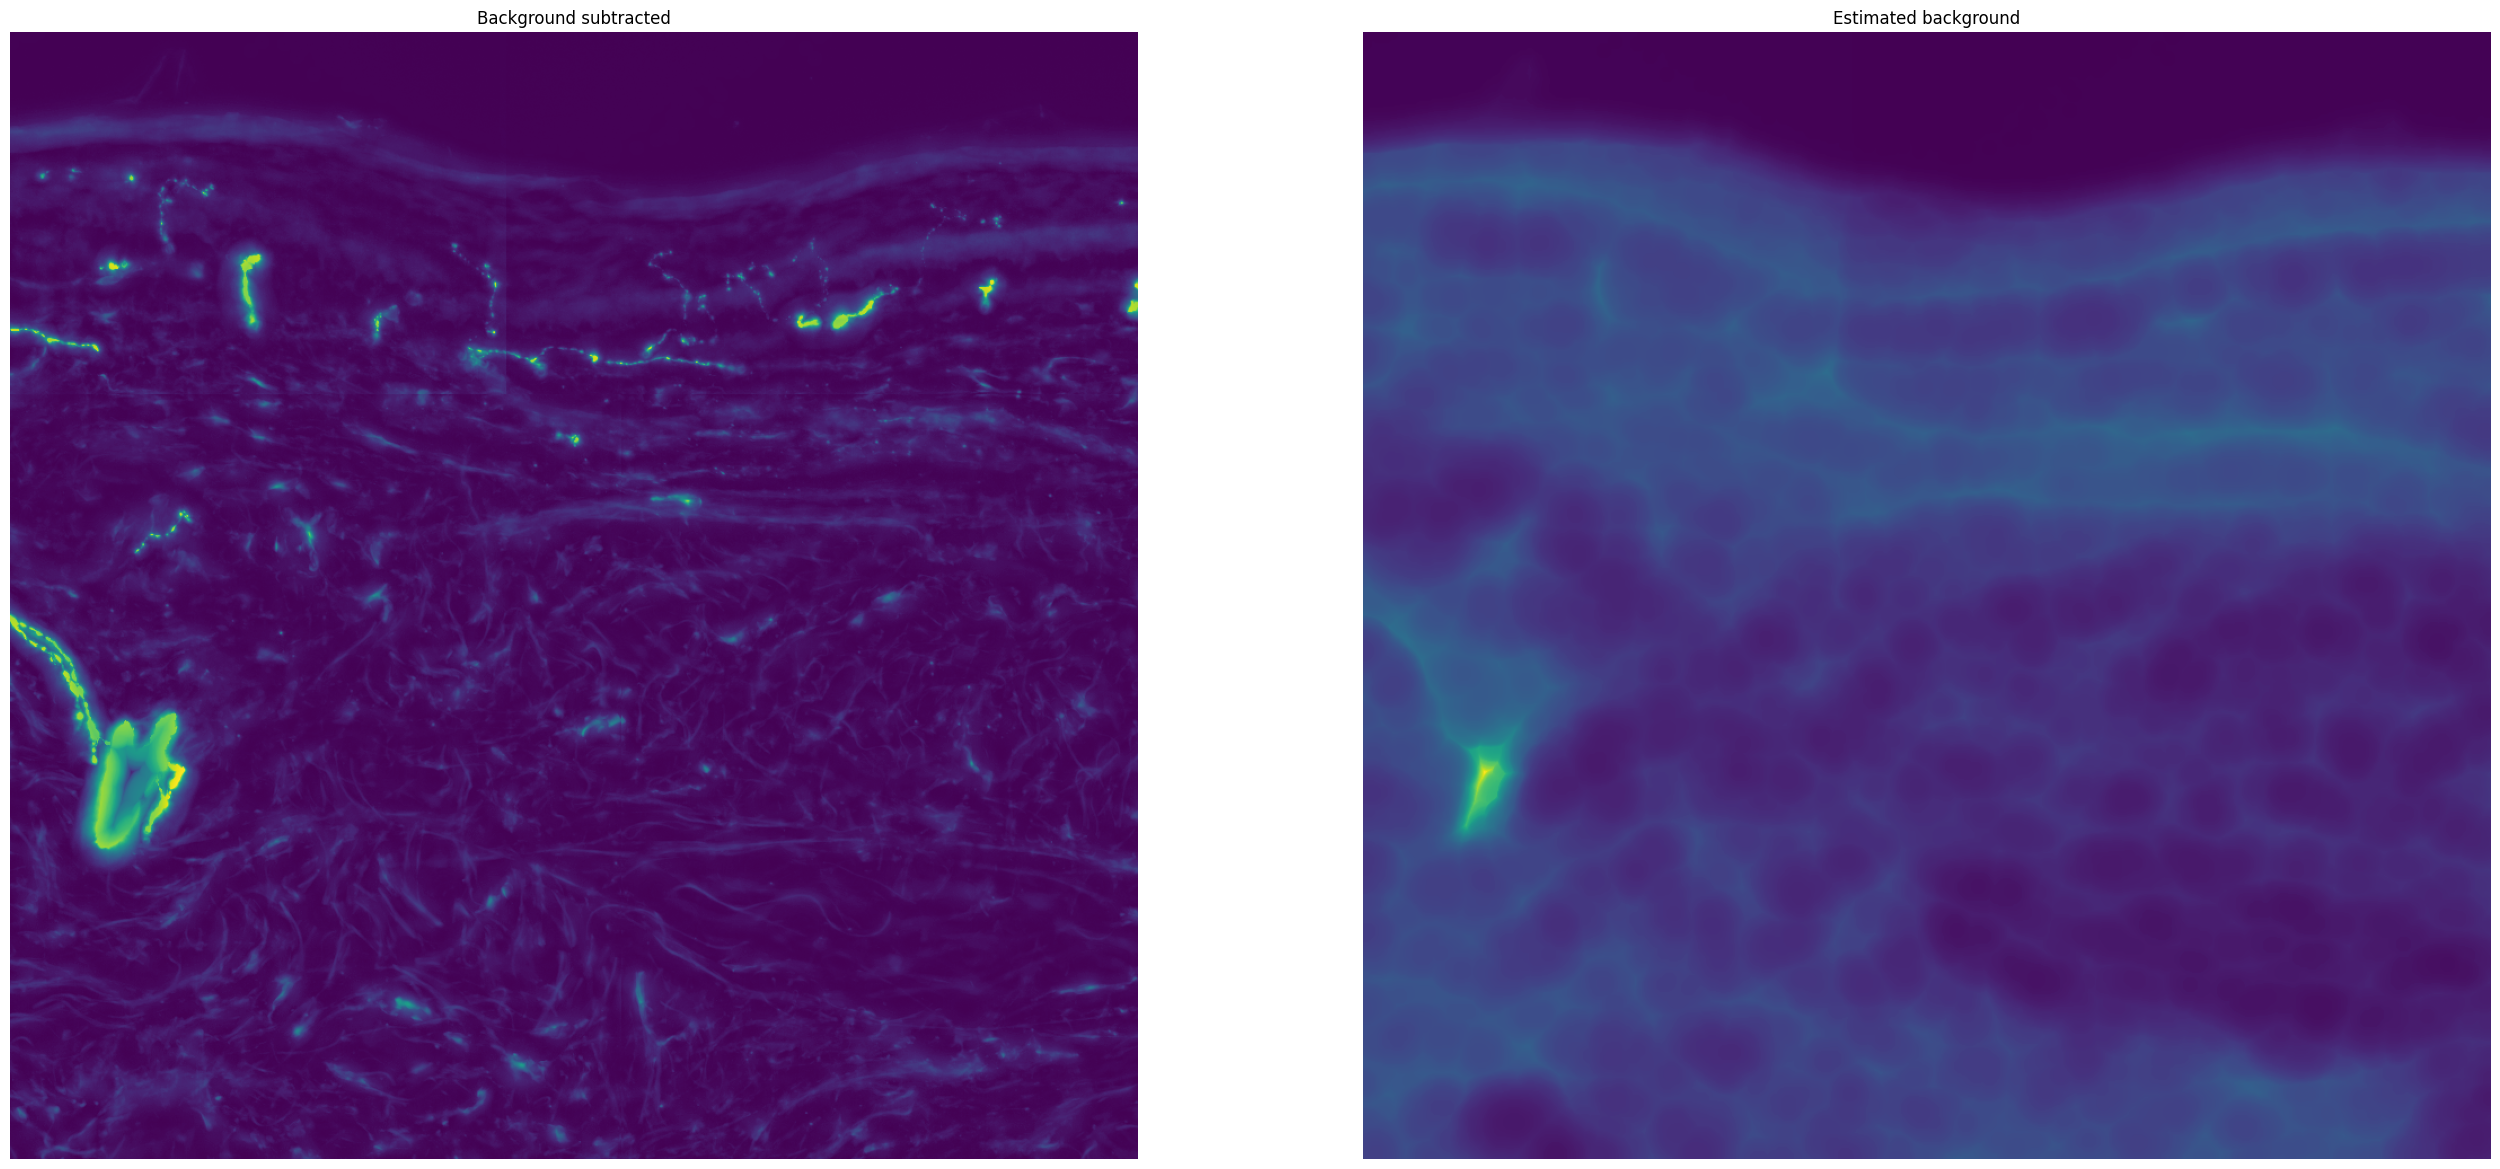

In [107]:
# apply rolling ball background subtraction
background = ski.restoration.rolling_ball(green_channel, radius=25)

# background = cv2.morphologyEx(green_channel, cv2.MORPH_OPEN,
# 							  cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (51, 51)))


corrected = green_channel - background
corrected[corrected < 0] = 0

_, ax = plt.subplots(1,2,figsize=(32, 16))
ax[0].imshow(corrected)
ax[0].set_axis_off()
_ = ax[0].set_title('Background subtracted')

ax[1].imshow(background)
ax[1].set_axis_off()
_ = ax[1].set_title('Estimated background')

原圖平均亮度: 10.21
相減圖平均亮度: 10.21


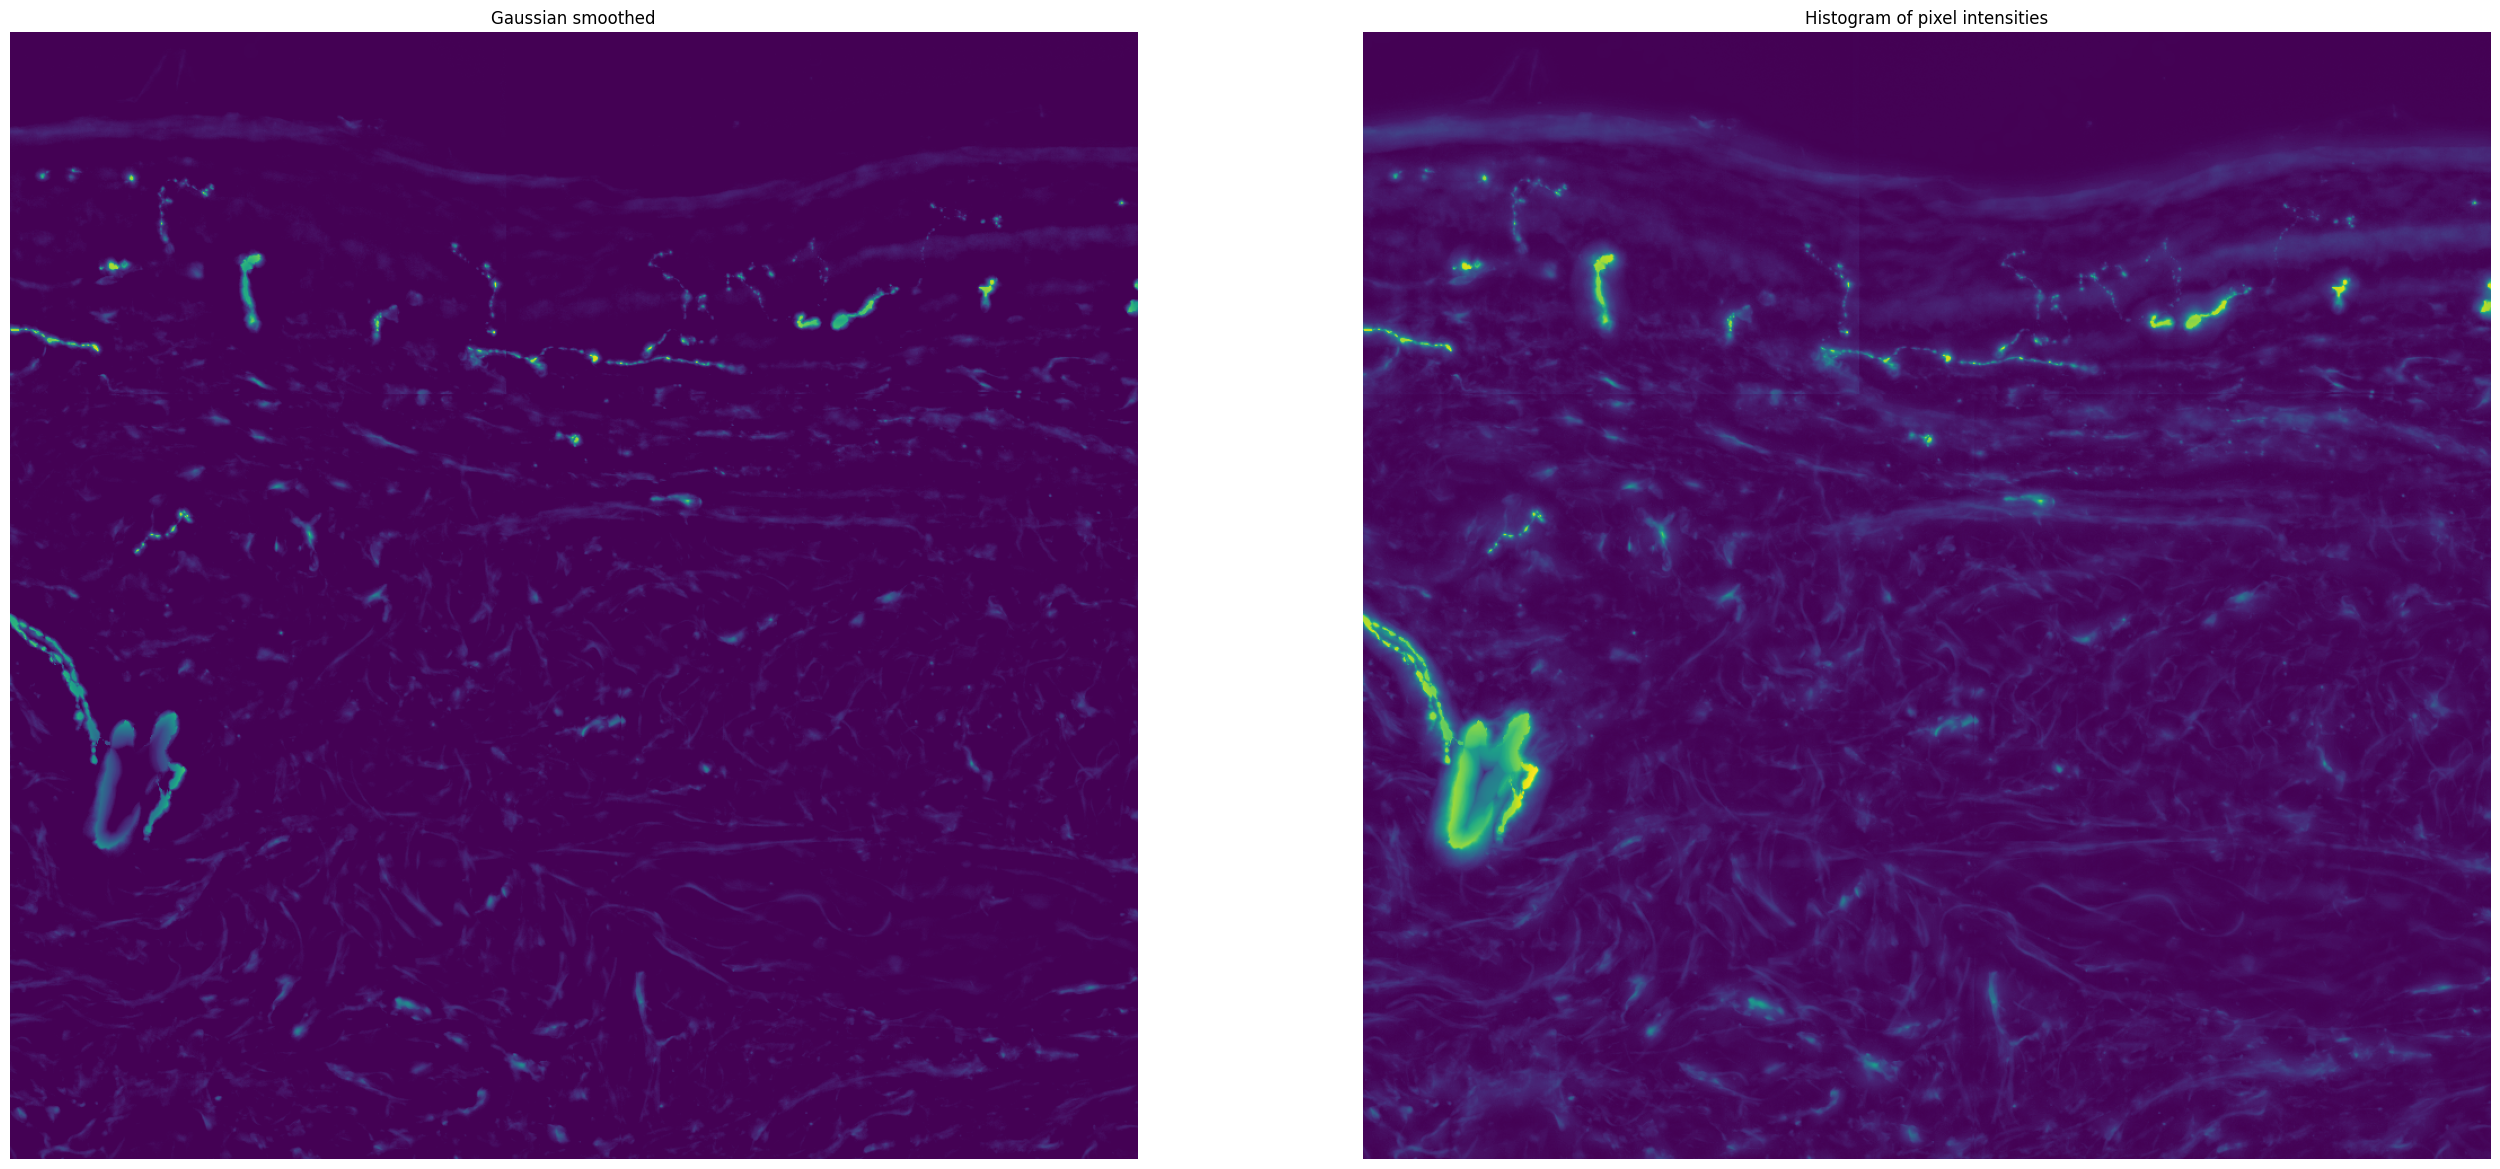

In [108]:
# apply gussian filter
smoothed = (ski.filters.gaussian(corrected, sigma=12) * 255).astype(np.float32)

gussian_result = corrected.astype(np.float32) - smoothed
gussian_result[gussian_result < 0] = 0

print(f"原圖平均亮度: {np.mean(corrected):.2f}")
print(f"相減圖平均亮度: {np.mean(smoothed):.2f}") # 這邊應該會接近 0

_, ax = plt.subplots(1, 2,figsize=(32, 16))
ax[0].imshow(gussian_result, )
ax[0].set_axis_off()
_ = ax[0].set_title('Gaussian smoothed')

ax[1].imshow(corrected)
ax[1].set_title('Histogram of pixel intensities')
ax[1].set_axis_off()
plt.show()